# OTT 재구매율(Churn) 예측 모델
- 데이터: `data/Membership_clean.csv` (원본 CSV 기반 전처리 완료)
- 모델: Logistic Regression → Random Forest → XGBoost → LightGBM
- 평가: AUC-ROC, F1, Accuracy, Confusion Matrix

## 1. 라이브러리 및 데이터 로드

In [21]:
import sys
!{sys.executable} -m pip install xgboost lightgbm -q

In [48]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    classification_report, confusion_matrix, RocCurveDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

df = pd.read_csv('../data/Membership_processing.csv')
print(f'shape: {df.shape}')
print(f"재결제(1): {df['repurchase'].sum()}명  이탈(0): {(df['repurchase']==0).sum()}명")
df.head(3)

shape: (17815, 31)
재결제(1): 11869명  이탈(0): 5946명


,user_no,product_cd,amount,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,...,is_night_signup,reg_weekday,is_same_day_cancel,age_group,total_watch_count,total_watch_duration,unique_movies,avg_duration,watch_days_count,has_watch_history
0,28d7d5684cce693a6a114cdabe2098875a894f3efaa4df...,pk_1508,11429.0,140,1,0,0,1,ios,N,...,0,5,0,40,16.0,718.0,12.0,44.875000,8.0,1
1,0da56ce994776bca14b522ab70bbfc70079fb34850fb4a...,pk_1508,11429.0,140,1,0,0,0,ios,N,...,0,1,0,30,4.0,287.0,4.0,71.750000,1.0,1
2,347d2fcd8e30072c1051fc617852bc7e70c13e3ecaac50...,pk_1508,11429.0,140,1,0,0,1,ios,N,...,0,5,0,40,3.0,124.0,3.0,41.333333,3.0,1


DROP_COLS = ['user_no', 'reg_date', 'end_date', 'product_cd',
             'billing_method', 'is_user_verified']

CAT_COLS = ['billing_group', 'plan_tier', 'currency_type', 'gender', 'payment_device']

df_model = df.drop(columns=DROP_COLS).copy()

# EDA 발견: 미인증 유저(is_verified==0)의 age는 신뢰 불가
# → age=40 spike가 미인증 기본값으로 추정됨
# → 미인증 유저 age를 NaN 처리 후 인증 유저 중앙값으로 대체
unverified_mask = df_model['is_verified'] == 0
verified_age_median = df_model.loc[~unverified_mask, 'age'].median()
df_model.loc[unverified_mask, 'age'] = np.nan
df_model['age'] = df_model['age'].fillna(verified_age_median)

print(f'미인증 유저 age → NaN 후 중앙값({verified_age_median}세) 대체: {unverified_mask.sum()}명')

# 범주형 → Label Encoding
le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le
    print(f'{col}: {dict(enumerate(le.classes_))}')

TARGET = 'repurchase'
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

print(f'\n피처 수: {len(FEATURES)}')
print('피처 목록:', FEATURES)

In [49]:
DROP_COLS = ['user_no', 'reg_date', 'end_date', 'product_cd',
             'billing_method', 'is_user_verified']

CAT_COLS = ['billing_group', 'plan_tier', 'currency_type', 'gender', 'payment_device']

df_model = df.drop(columns=DROP_COLS).copy()

# 범주형 → Label Encoding
le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le
    print(f'{col}: {dict(enumerate(le.classes_))}')

TARGET = 'repurchase'
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

print(f'\n피처 수: {len(FEATURES)}')
print('피처 목록:', FEATURES)

billing_group: {0: 'iOS', 1: '간편결제', 2: '국내카드', 3: '기타', 4: '모바일'}
plan_tier: {0: 'basic', 1: 'premium', 2: 'standard', 3: '기타'}
currency_type: {0: 'KRW', 1: 'USD'}
gender: {0: 'F', 1: 'M'}
payment_device: {0: 'android', 1: 'ios', 2: 'lgchplus', 3: 'lgtv', 4: 'mobile', 5: 'ott', 6: 'ott_cjhello', 7: 'pc', 8: 'smarttv', 9: 'sstv'}

피처 수: 24
피처 목록: ['amount', 'concurrent_streams', 'promotion_yn', 'is_churn_prevented', 'payment_device', 'gender', 'age', 'reg_hour', 'duration_days', 'is_verified', 'billing_group', 'plan_tier', 'currency_type', 'is_promotional_price', 'is_night_signup', 'reg_weekday', 'is_same_day_cancel', 'age_group', 'total_watch_count', 'total_watch_duration', 'unique_movies', 'avg_duration', 'watch_days_count', 'has_watch_history']


## 3. Train / Test Split (8:2, Stratified)

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]}개  (재결제: {y_train.sum()}, 이탈: {(y_train==0).sum()})')
print(f'Test:  {X_test.shape[0]}개  (재결제: {y_test.sum()}, 이탈: {(y_test==0).sum()})')

# LR용 스케일링
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: 14252개  (재결제: 9495, 이탈: 4757)
Test:  3563개  (재결제: 2374, 이탈: 1189)


## 4. 공통 평가 함수

In [51]:
results = {}

def evaluate(name, model, X_tr, X_te, y_tr, y_te, proba=True):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1] if proba else y_pred
    auc  = roc_auc_score(y_te, y_prob)
    f1   = f1_score(y_te, y_pred)
    acc  = accuracy_score(y_te, y_pred)
    results[name] = {'AUC': round(auc,4), 'F1': round(f1,4), 'Accuracy': round(acc,4),
                     'model': model, 'y_prob': y_prob, 'y_pred': y_pred}
    print(f'[{name}]  AUC: {auc:.4f}  F1: {f1:.4f}  Accuracy: {acc:.4f}')
    return model

## 5. Logistic Regression

In [52]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
evaluate('Logistic Regression', lr, X_train_sc, X_test_sc, y_train, y_test)

print('\nClassification Report:')
print(classification_report(y_test, results['Logistic Regression']['y_pred'],
                            target_names=['이탈(0)','재결제(1)']))

[Logistic Regression]  AUC: 0.6432  F1: 0.6753  Accuracy: 0.6040

Classification Report:
              precision    recall  f1-score   support

       이탈(0)       0.43      0.58      0.49      1189
      재결제(1)       0.74      0.62      0.68      2374

    accuracy                           0.60      3563
   macro avg       0.59      0.60      0.58      3563
weighted avg       0.64      0.60      0.61      3563



## 6. Random Forest

In [53]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
evaluate('Random Forest', rf, X_train, X_test, y_train, y_test)

print('\nClassification Report:')
print(classification_report(y_test, results['Random Forest']['y_pred'],
                            target_names=['이탈(0)','재결제(1)']))

[Random Forest]  AUC: 0.6737  F1: 0.7334  Accuracy: 0.6537

Classification Report:
              precision    recall  f1-score   support

       이탈(0)       0.48      0.53      0.51      1189
      재결제(1)       0.75      0.71      0.73      2374

    accuracy                           0.65      3563
   macro avg       0.62      0.62      0.62      3563
weighted avg       0.66      0.65      0.66      3563



## 7. XGBoost

In [54]:
scale_pos = (y_train == 0).sum() / y_train.sum()  # 클래스 불균형 보정

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=42, n_jobs=-1, eval_metric='auc',
    verbosity=0
)
evaluate('XGBoost', xgb, X_train, X_test, y_train, y_test)

print('\nClassification Report:')
print(classification_report(y_test, results['XGBoost']['y_pred'],
                            target_names=['이탈(0)','재결제(1)']))

[XGBoost]  AUC: 0.6656  F1: 0.7303  Accuracy: 0.6517

Classification Report:
              precision    recall  f1-score   support

       이탈(0)       0.48      0.54      0.51      1189
      재결제(1)       0.75      0.71      0.73      2374

    accuracy                           0.65      3563
   macro avg       0.62      0.62      0.62      3563
weighted avg       0.66      0.65      0.66      3563



## 8. LightGBM

In [55]:
lgbm = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1
)
evaluate('LightGBM', lgbm, X_train, X_test, y_train, y_test)

print('\nClassification Report:')
print(classification_report(y_test, results['LightGBM']['y_pred'],
                            target_names=['이탈(0)','재결제(1)']))

[LightGBM]  AUC: 0.6657  F1: 0.7328  Accuracy: 0.6542

Classification Report:
              precision    recall  f1-score   support

       이탈(0)       0.48      0.54      0.51      1189
      재결제(1)       0.76      0.71      0.73      2374

    accuracy                           0.65      3563
   macro avg       0.62      0.63      0.62      3563
weighted avg       0.66      0.65      0.66      3563



## 9. 모델 비교

                        AUC      F1  Accuracy
Random Forest        0.6737  0.7334    0.6537
LightGBM             0.6657  0.7328    0.6542
XGBoost              0.6656  0.7303    0.6517
Logistic Regression  0.6432  0.6753    0.6040


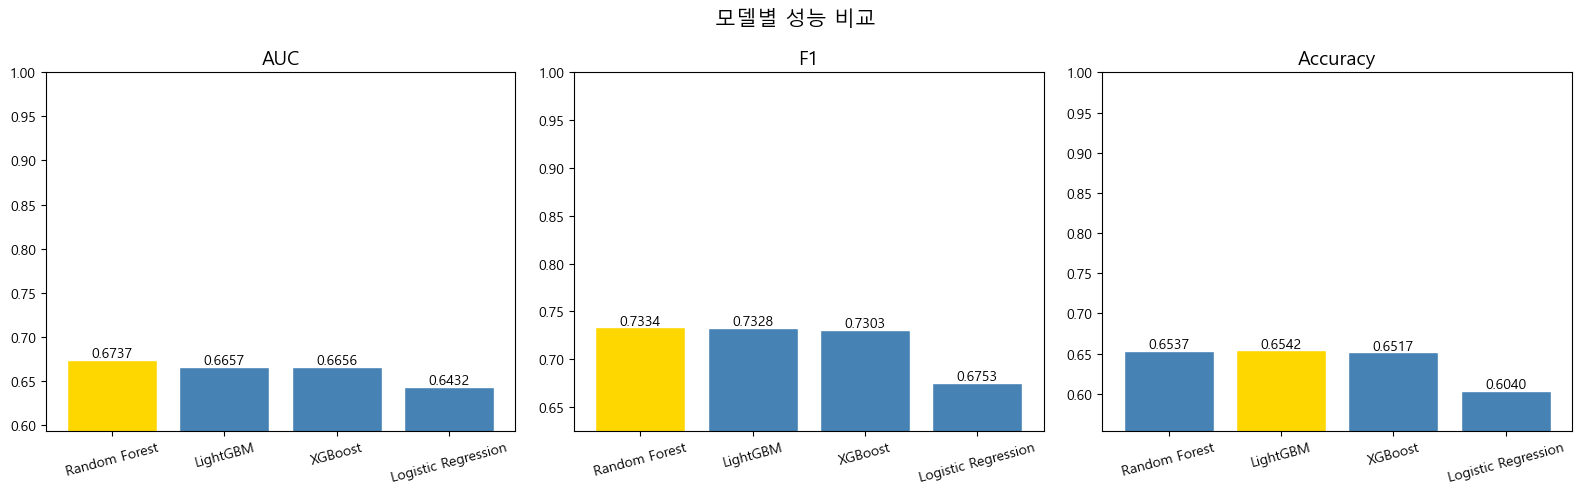

In [56]:
# 성능 표
compare_df = pd.DataFrame({
    k: {m: v[m] for m in ['AUC','F1','Accuracy']}
    for k, v in results.items()
}).T.sort_values('AUC', ascending=False)
print(compare_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['AUC', 'F1', 'Accuracy']):
    vals = compare_df[metric]
    colors = ['gold' if i == vals.argmax() else 'steelblue' for i in range(len(vals))]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white')
    ax.set_title(metric, fontsize=14)
    ax.set_ylim(vals.min() - 0.05, 1.0)
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('모델별 성능 비교', fontsize=15)
plt.tight_layout()
plt.show()

## 10. ROC Curve 비교

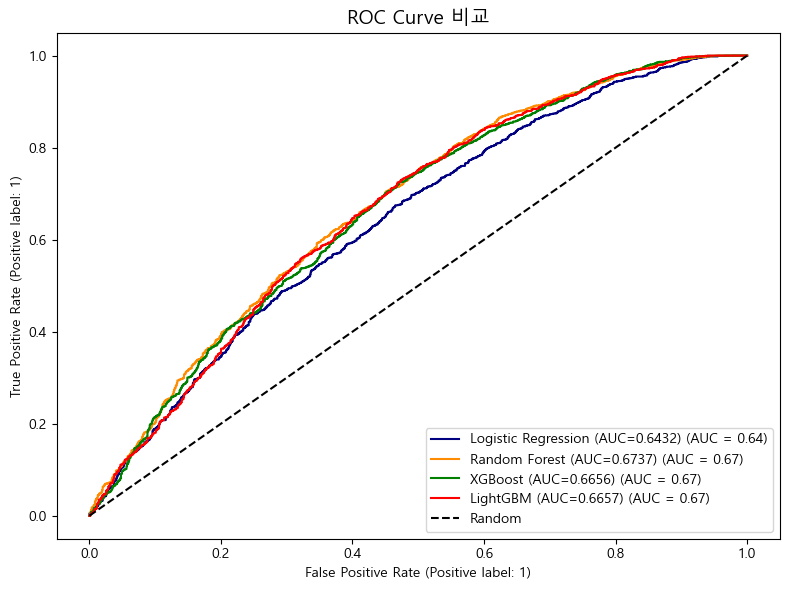

In [57]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['navy', 'darkorange', 'green', 'red']
for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, res['y_prob'],
        name=f"{name} (AUC={res['AUC']:.4f})",
        ax=ax, color=color
    )
ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_title('ROC Curve 비교', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 11. Confusion Matrix

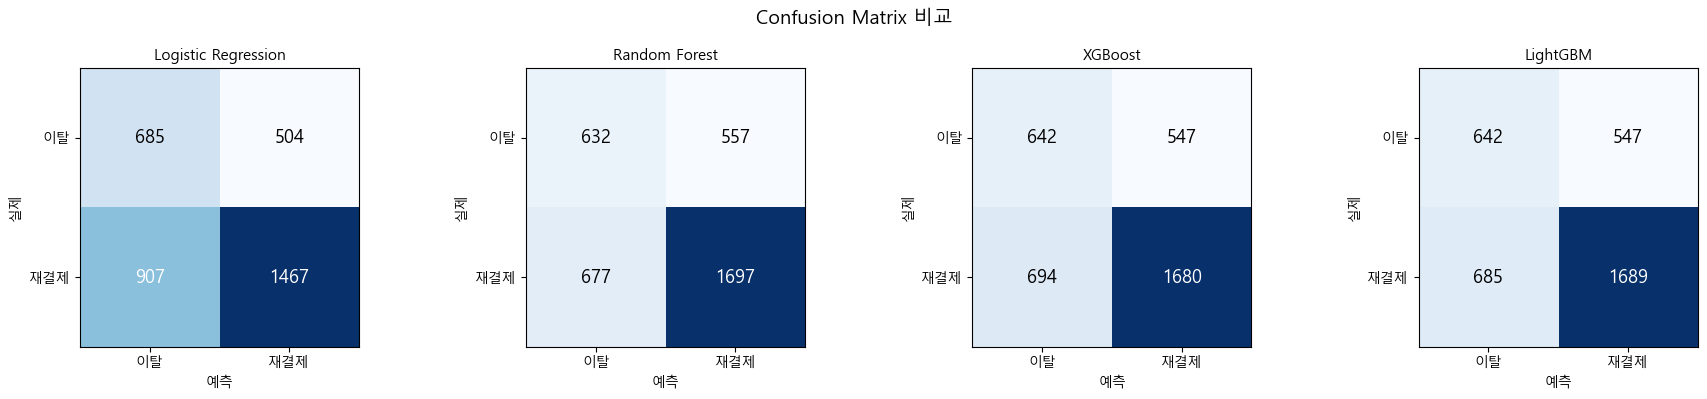

In [58]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('예측')
    ax.set_ylabel('실제')
    ax.set_xticks([0,1]); ax.set_xticklabels(['이탈','재결제'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['이탈','재결제'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=13)
plt.suptitle('Confusion Matrix 비교', fontsize=14)
plt.tight_layout()
plt.show()

## 12. 피처 중요도
최고 AUC 모델 기준

최고 모델: Random Forest (AUC=0.6737)


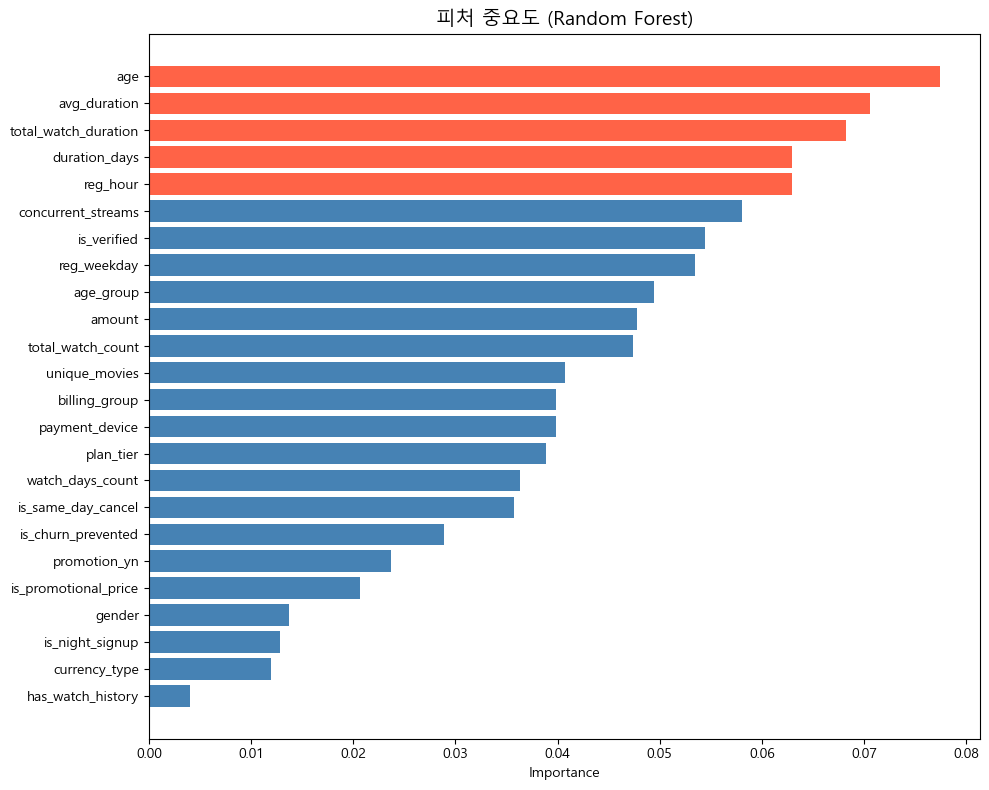


Top 10 중요 피처:
age                     0.0774
avg_duration            0.0706
total_watch_duration    0.0683
duration_days           0.0630
reg_hour                0.0630
concurrent_streams      0.0580
is_verified             0.0544
reg_weekday             0.0535
age_group               0.0494
amount                  0.0478


In [59]:
best_name = compare_df['AUC'].idxmax()
best_model = results[best_name]['model']
print(f'최고 모델: {best_name} (AUC={compare_df["AUC"].max():.4f})')

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=FEATURES)
else:
    imp = pd.Series(np.abs(best_model.coef_[0]), index=FEATURES)

imp = imp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if i < 5 else 'steelblue' for i in range(len(imp))]
ax.barh(imp.index[::-1], imp.values[::-1], color=colors[::-1])
ax.set_title(f'피처 중요도 ({best_name})', fontsize=14)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 10 중요 피처:')
print(imp.head(10).round(4).to_string())

## 13. 5-Fold Cross Validation (최고 모델)

In [ ]:
best_model_cv = results[best_name]['model'].__class__(**results[best_name]['model'].get_params())

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(best_model_cv, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_f1  = cross_val_score(best_model_cv, X, y, cv=cv, scoring='f1', n_jobs=-1)

print(f'{best_name} - 5-Fold CV 결과')
print(f'AUC:  {cv_auc.mean():.4f} ± {cv_auc.std():.4f}  ({cv_auc})')
print(f'F1:   {cv_f1.mean():.4f} ± {cv_f1.std():.4f}  ({cv_f1})')

Random Forest - 5-Fold CV 결과
AUC:  0.6763 ± 0.0070  ([0.68281913 0.66648983 0.67573864 0.68526113 0.67135598])
F1:   0.7380 ± 0.0061  ([0.73495019 0.73031753 0.74658828 0.74380521 0.73445596])


: 